# Training BLISSNet

In [2]:
#!git clone https://github.com/syeddaniyalg/blissnet-era5-inference

In [3]:
# import shutil, sys
# shutil.copy("/kaggle/input/datasets/thesyeddaniyal/south-asia-era5-t2m-2025-6h/south_asia_t2m.nc","/kaggle/working/blissnet-era5-inference/datasets")
# sys.path.append('/kaggle/working/blissnet-era5-inference/')

In [4]:
from blissnet.blissnet import BLISSNet
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import xarray
import torch.optim as optim
from tqdm import tqdm
from dataclasses import dataclass

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## Dataset Initialization

In [5]:
class T2MDataset(Dataset):
    def __init__(self, path, transform=None):
        super().__init__()
        xarray_ds = xarray.open_dataset(path)

        ds_t2m = torch.from_numpy(xarray_ds['t2m'].to_numpy())
        T, H, W = ds_t2m.shape
        ds_t2m = list(ds_t2m.reshape(T, -1).unsqueeze(dim=-1).unbind(dim=0))

        vec_lat = torch.from_numpy(xarray_ds.latitude.to_numpy())
        vec_long = torch.from_numpy(xarray_ds.longitude.to_numpy())
        arr_lat, arr_long = torch.meshgrid([vec_lat, vec_long], indexing='ij')
        grid_coord = list(torch.stack([arr_lat, arr_long], dim=-1).reshape(H*W,2).unsqueeze(0).expand(T, H*W, 2).unbind(dim=0))

        self.H = H
        self.W = W
        self.T = T
        self.dataset = list(zip(ds_t2m, grid_coord))
        ds_t2m_raw = torch.from_numpy(xarray_ds['t2m'].to_numpy()) 
        self.transform = transform
        
    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        if index >= len(self.dataset) or index < 0:
            raise IndexError

        item = self.dataset[index]
        if self.transform is not None:
            item = self.transform(item)

        return item

In [6]:
class DatasetScalar:
    def __init__(self, t2m_min=200.0, t2m_max=340.0,
                 lat_min=-90.0, lat_max=90.0,
                 long_min=-180.0, long_max=180.0):
        self.t2m_min = t2m_min
        self.t2m_max = t2m_max
        self.coord_min = torch.tensor([lat_min, long_min], dtype=torch.float32)
        self.coord_max = torch.tensor([lat_max, long_max], dtype=torch.float32)

    def norm_t2m(self, t2m):
        t2m = 2 * (t2m - self.t2m_min) / (self.t2m_max - self.t2m_min) - 1
        return t2m.clamp(-1, 1)
    
    def denorm_t2m(self, t2m):
        return (t2m + 1) / 2 * (self.t2m_max - self.t2m_min) + self.t2m_min
    
    def norm_coord(self, coord):
        coord_min = self.coord_min.to(coord.device)
        coord_max = self.coord_max.to(coord.device)
        return 2 * (coord - coord_min) / (coord_max - coord_min) - 1
    
    def denorm_coord(self, coord):
        coord_min = self.coord_min.to(coord.device)
        coord_max = self.coord_max.to(coord.device)
        return (coord + 1) / 2 * (coord_max - coord_min) + coord_min

    def norm(self, sample):
        t2m, coord = sample
        return self.norm_t2m(t2m), self.norm_coord(coord)

    def denorm(self, sample):
        t2m, coord = sample
        return self.denorm_t2m(t2m), self.denorm_coord(coord)

    def __call__(self, sample):
        return self.norm(sample)

In [7]:
scalar = DatasetScalar()

In [8]:
dataset_dir = "./datasets/"
south_asia_dataset = T2MDataset(f'{dataset_dir}/south_asia_t2m.nc', transform=scalar)
punjab_dataset = T2MDataset(f'{dataset_dir}/punjab_t2m.nc', transform=scalar)
karnatka_dataset = T2MDataset(f'{dataset_dir}/karnatka_t2m.nc', transform=scalar)

## Training BLISSNet

In [9]:
class BLISSNetTrainer():
    def __init__(self, dataset:T2MDataset, config, device=None, parallel=True):
        self.config = config
        self.device = device
        if self.device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        dataset_size = len(dataset)
        train_size = int(0.9 * dataset_size)
        test_size = dataset_size - train_size

        trainset, testset = random_split(dataset, [train_size, test_size])
        self.trainloader = DataLoader(trainset, batch_size=config.batch_size, shuffle=True)
        self.testloader = DataLoader(testset, batch_size=config.batch_size, shuffle=False)

        self.transform = dataset.transform
        self.dataset_params = {'H':dataset.H, 'W':dataset.W, 'T':dataset.T}

        self.model = BLISSNet(config.emb_dim, dataset.H, dataset.W, config.K, config.n_heads, config.dropout).to(self.device)
        
        self.epochs = config.epochs
        self.lr = config.lr
        
        self.TRAIN_LOSSES_S1 = []
        self.TEST_LOSSES_S1 = []

        self.TRAIN_LOSSES_S2 = []
        self.TEST_LOSSES_S2 = []

        self.TRAIN_METRICS_S1 = []  
        self.TEST_METRICS_S1 = []
        
        self.TRAIN_METRICS_S2 = []
        self.TEST_METRICS_S2 = []

        self.TRAIN_LOSSES_S2_COMPONENTS = []
        self.TEST_LOSSES_S2_COMPONENTS = []

        self.parallel = parallel

    def generate_subsets(self, t2m_batch, coord_batch):
        B, N, _ = t2m_batch.shape
        min_size = max(1, int(0.005 * N))
        max_size = max(min_size + 1, int(0.05 * N))
        size = int(torch.randint(min_size, max_size, (1,)).item())

        indices = torch.rand(B, N, device=t2m_batch.device).argsort(dim=1)[:, :size]

        t2m_indices = indices.unsqueeze(-1)
        coord_indices = indices.unsqueeze(-1).expand(-1, -1, 2)

        subset_t2m = torch.gather(t2m_batch, dim=1, index=t2m_indices)
        subset_coord = torch.gather(coord_batch, dim=1, index=coord_indices)
        return subset_t2m, subset_coord, indices

    def lossEP(self, input_subset, output_recon, indices, lambda_ep):
        B, _, H, W = output_recon.shape
        output_recon = output_recon.reshape(B, 1, H*W).permute(0, 2, 1)
        t2m_indices = indices.unsqueeze(-1)
        output_subset = torch.gather(output_recon, dim=1, index=t2m_indices) # B, subset_size, 1
        mse = nn.MSELoss()
        return lambda_ep * mse(output_subset, input_subset)

    def lossEMB(self, input_emb, target_emb, lambda_emb):
        mse = nn.MSELoss()
        return lambda_emb * mse(target_emb, input_emb)

    def lossCoeff(self, input_coeff, target_coeff, lambda_coeff):
        mse = nn.MSELoss(reduction='none')
        diff_sq = mse(target_coeff, input_coeff)
        
        l2_diff = torch.sqrt(torch.sum(diff_sq, dim=1))
        l2_true = torch.sqrt(torch.sum(target_coeff ** 2, dim=1))
        
        l_coeff = torch.mean(l2_diff / (l2_true + 1e-8))
        return lambda_coeff * l_coeff

    def lossGT(self, input_t2m, target_t2m, lambda_gt):
        mse = nn.MSELoss(reduction='none')
        diff_sq = mse(target_t2m, input_t2m)

        l2_diff = torch.sqrt(torch.sum(diff_sq, dim=(1,2,3)))
        l2_true = torch.sqrt(torch.sum(input_t2m ** 2, dim=(1,2,3)))

        l_gt = torch.mean(l2_diff / (l2_true + 1e-8))
        return lambda_gt * l_gt

    def rmse(self, pred, target):
        return torch.sqrt(torch.mean((pred - target) ** 2)).item()

    def mae(self, pred, target):
        return torch.mean(torch.abs(pred - target)).item()

    def bias(self, pred, target):
        return torch.mean(pred - target).item()

    def r2_score(self, pred, target):
        ss_res = torch.sum((target - pred) ** 2)
        ss_tot = torch.sum((target - target.mean()) ** 2)
        return (1 - ss_res / (ss_tot + 1e-8)).item()

    def compute_metrics(self, pred, target):
        pred = pred.float()
        target = target.float()
        return {
            'rmse': self.rmse(pred, target),
            'mae': self.mae(pred, target),
            'bias': self.bias(pred, target),
            'r2_percent': max(0.0, self.r2_score(pred, target)) * 100,
        }
        
    def _accumulate(self, running: dict, batch_metrics: dict, batch_size: int):
        for k, v in batch_metrics.items():
            running[k] = running.get(k, 0.0) + v * batch_size

    def _average(self, running: dict, total: int):
        return {k: v / total for k, v in running.items()}

    def train_stage1(self):
            criterion = nn.MSELoss()
            self.model.train(True)
            running_train_loss = 0
            running_test_loss = 0
            total = 0
            running_train_metrics = {}
            self.scaler = torch.amp.GradScaler('cuda')
            for t2m, coord in tqdm(self.trainloader):
            
                self.optimizer.zero_grad()
                with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', dtype=torch.float16):
                    t2m = t2m.to(self.device) # shape: B, N, 1
                    coord = coord.to(self.device)
                    B, N, _ = t2m.shape
                    H, W = self.dataset_params['H'], self.dataset_params['W']
                    t2m = t2m.permute(0, 2, 1).reshape(B, 1, H, W)
                    bounds = (coord[..., 0].min(), coord[..., 0].max(), coord[..., 1].min(), coord[..., 1].max())
                    output, _, _ = self.model(t2m, (H, W), bounds, phase=0)
                    
                    
                    loss = criterion(output, t2m)
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.scaler.step(self.optimizer)
                self.scaler.update()
    
                total += B
                running_train_loss += loss.item() * B
                pred_K = self.transform.denorm_t2m(output.detach())
                target_K = self.transform.denorm_t2m(t2m.detach())
                batch_metrics = self.compute_metrics(pred_K, target_K)  
                self._accumulate(running_train_metrics, batch_metrics, B) 
                avg_train_metrics = self._average(running_train_metrics, total)
            
            avg_train_loss = running_train_loss / total
    
            with torch.no_grad():
                self.model.eval()
                total = 0
                running_test_metrics = {}
                for t2m, coord in tqdm(self.testloader):
                    with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', dtype=torch.float16):
                        t2m = t2m.to(self.device) # shape: B, N, 1
                        coord = coord.to(self.device)
                        B, N, _ = t2m.shape
                        H, W = self.dataset_params['H'], self.dataset_params['W']
                        t2m = t2m.permute(0, 2, 1).reshape(B, 1, H, W)
                        bounds = (coord[..., 0].min(), coord[..., 0].max(), coord[..., 1].min(), coord[..., 1].max())
                        output, _, _ = self.model(t2m, (H, W), bounds, phase=0)
                        loss = criterion(output, t2m)
                
                    total += B
                    running_test_loss += loss.item() * B
                    pred_K = self.transform.denorm_t2m(output.detach())
                    target_K = self.transform.denorm_t2m(t2m.detach())
                    batch_metrics = self.compute_metrics(pred_K, target_K)                 
                    self._accumulate(running_test_metrics, batch_metrics, B)
    
            
            avg_test_loss = running_test_loss / total
            avg_test_metrics = self._average(running_test_metrics, total)
    
            return avg_train_loss, avg_test_loss, avg_train_metrics, avg_test_metrics
    
    def train_stage2(self, lambda_ep, lambda_emb, lambda_coeff, lambda_gt):
        self.model.train(True)
        if self.parallel:
            self.model.module.branch1.eval()
            self.model.module.trunk_net.eval()
        else:
            self.model.branch1.eval()
            self.model.trunk_net.eval()
            
        running_train_loss = 0
        running_test_loss = 0
        running_train_metrics = {}
        running_train_components = {}
        total = 0
        self.scaler = torch.amp.GradScaler('cuda')
        for t2m, coord in tqdm(self.trainloader):
            self.optimizer.zero_grad()
            with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', dtype=torch.float16):
                t2m, coord = t2m.to(self.device).float(), coord.to(self.device).float()
                B, N, _ = t2m.shape
                H, W = self.dataset_params['H'], self.dataset_params['W']
                t2m_grid = t2m.permute(0, 2, 1).reshape(B, 1, H, W)
                bounds = (coord[..., 0].min(), coord[..., 0].max(), coord[..., 1].min(), coord[..., 1].max())
                subset_t2m, subset_coord, subset_indices = self.generate_subsets(t2m, coord)
                subset_t2m, subset_coord = subset_t2m.float(), subset_coord.float()
                output, coeff_stage2, emb_stage2 = self.model((subset_t2m, subset_coord), (H, W), bounds, phase=1)
                _, coeff_stage1, emb_stage1 = self.model(t2m_grid, (H, W), bounds, phase=0)
    
                loss_ep = self.lossEP(subset_t2m, output, subset_indices, lambda_ep)
                loss_emb = self.lossEMB(emb_stage2, emb_stage1, lambda_emb)
                loss_coeff = self.lossCoeff(coeff_stage2, coeff_stage1, lambda_coeff)
                loss_gt = self.lossGT(t2m_grid, output, lambda_gt)
    
                loss = loss_ep + loss_emb + loss_coeff + loss_gt
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.scaler.step(self.optimizer)
            self.scaler.update()
            
            running_train_loss += loss.item() * B
            total += B
            batch_components = {'ep': loss_ep.item(), 'emb': loss_emb.item(), 'coeff': loss_coeff.item(), 'gt': loss_gt.item()}
            self._accumulate(running_train_components, batch_components, B)
            pred_K = self.transform.denorm_t2m(output.detach())
            target_K = self.transform.denorm_t2m(t2m_grid.detach())
            batch_metrics = self.compute_metrics(pred_K, target_K)
            self._accumulate(running_train_metrics, batch_metrics, B)

        avg_train_loss = running_train_loss / total
        avg_train_metrics = self._average(running_train_metrics, total)
        avg_train_components = self._average(running_train_components, total)

        with torch.no_grad():
            self.model.eval()
            total = 0
            running_test_metrics = {}
            running_test_components = {}
            for t2m, coord in tqdm(self.testloader):
                with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', dtype=torch.float16):
                    t2m, coord = t2m.to(self.device).float(), coord.to(self.device).float()
                    B, N, _ = t2m.shape
                    H, W = self.dataset_params['H'], self.dataset_params['W']
                    t2m_grid = t2m.permute(0, 2, 1).reshape(B, 1, H, W)
                    bounds = (coord[..., 0].min(), coord[..., 0].max(), coord[..., 1].min(), coord[..., 1].max())
                    subset_t2m, subset_coord, subset_indices = self.generate_subsets(t2m, coord)
                    subset_t2m = subset_t2m.float()
                    subset_coord = subset_coord.float()
                    output, coeff_stage2, emb_stage2 = self.model((subset_t2m, subset_coord), (H, W), bounds, phase=1)
                    _, coeff_stage1, emb_stage1 = self.model(t2m_grid, (H, W), bounds, phase=0)
        
                    loss_ep = self.lossEP(subset_t2m, output, subset_indices, lambda_ep)
                    loss_emb = self.lossEMB(emb_stage2, emb_stage1, lambda_emb)
                    loss_coeff = self.lossCoeff(coeff_stage2, coeff_stage1, lambda_coeff)
                    loss_gt = self.lossGT(t2m_grid, output, lambda_gt)
    
                    loss = loss_ep + loss_emb + loss_coeff + loss_gt
        
                running_test_loss += loss.item() * B
                total += B
                batch_components = {'ep': loss_ep.item(), 'emb': loss_emb.item(), 'coeff': loss_coeff.item(), 'gt': loss_gt.item()}
                self._accumulate(running_test_components, batch_components, B)
                pred_K = self.transform.denorm_t2m(output.detach())
                target_K = self.transform.denorm_t2m(t2m_grid.detach())
                batch_metrics = self.compute_metrics(pred_K, target_K)                 
                self._accumulate(running_test_metrics, batch_metrics, B)               

        avg_test_loss = running_test_loss / total
        avg_test_metrics = self._average(running_test_metrics, total)                  
        avg_test_components = self._average(running_test_components, total)

        self.TRAIN_LOSSES_S2_COMPONENTS.append(avg_train_components)
        self.TEST_LOSSES_S2_COMPONENTS.append(avg_test_components)

        return avg_train_loss, avg_test_loss, avg_train_metrics, avg_test_metrics 
            
    def train(self, lambda_ep, lambda_emb, lambda_coeff, lambda_gt):
        # stage 1
        print("========== Training Stage 1 ============")
        if self.parallel:
            self.model = nn.DataParallel(self.model)
            self.model.module.setPhase(0, self.config)
        else:
            self.model.setPhase(0, self.config)
        self.model.to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), self.lr)    
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, 
            mode='min', 
            factor=0.5, 
            patience=5,
        )
        for i in range(self.epochs):
            train_loss, test_loss, train_metrics, test_metrics = self.train_stage1()

            self.TRAIN_LOSSES_S1.append(train_loss)
            self.TEST_LOSSES_S1.append(test_loss)
            self.TRAIN_METRICS_S1.append(train_metrics)      
            self.TEST_METRICS_S1.append(test_metrics)   
            scheduler.step(test_loss)

            print(f"Epoch {i + 1} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} "
              f"| Test RMSE: {test_metrics['rmse']:.4f} | Test MAE: {test_metrics['mae']:.4f} "
              f"| Test R2: {test_metrics['r2_percent']:.2f}% | Test Bias: {test_metrics['bias']:.4f}")

        # stage 2
        print("========= Training Stage 2 ============")

        if self.parallel:
            self.model.module.setPhase(1, self.config)
        else:
            self.model.setPhase(1, self.config)
        self.model.to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), self.lr) 
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, 
            mode='min', 
            factor=0.5, 
            patience=5,
        )
        for i in range(self.epochs):
            train_loss, test_loss, train_metrics, test_metrics = self.train_stage2(lambda_ep, lambda_emb, lambda_coeff, lambda_gt)
            
            self.TRAIN_LOSSES_S2.append(train_loss)
            self.TEST_LOSSES_S2.append(test_loss)
            self.TRAIN_METRICS_S2.append(train_metrics)     
            self.TEST_METRICS_S2.append(test_metrics)
            scheduler.step(test_loss)
            print(f"Epoch {i + 1} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} "
              f"| Test RMSE: {test_metrics['rmse']:.4f} | Test MAE: {test_metrics['mae']:.4f} "
              f"| Test R2: {test_metrics['r2_percent']:.2f}% | Test Bias: {test_metrics['bias']:.4f}")

        if self.parallel:
            self.model = self.model.module

    def load(self, name):
        if not os.path.exists(f"./models/{name}_blissnet_chkpoint.pth"):
            return False

        with open(f"./models/{name}_blissnet_hist.pkl", 'rb') as file:
            data = pickle.load(file)
            self.TRAIN_LOSSES_S1 = data['train_loss_s1']
            self.TEST_LOSSES_S1 = data['test_loss_s1']
            self.TRAIN_LOSSES_S2 = data['train_loss_s2']
            self.TEST_LOSSES_S2 = data['test_loss_s2']
            self.TRAIN_METRICS_S1 = data.get('train_metrics_s1', []) 
            self.TEST_METRICS_S1 = data.get('test_metrics_s1', [])      
            self.TRAIN_METRICS_S2 = data.get('train_metrics_s2', [])    
            self.TEST_METRICS_S2 = data.get('test_metrics_s2', [])      
            self.TRAIN_LOSSES_S2_COMPONENTS = data.get('train_loss_s2_components', [])
            self.TEST_LOSSES_S2_COMPONENTS = data.get('test_loss_s2_components', [])

        self.model.setPhase(0, self.config)
        self.model.setPhase(1, self.config)
        self.model.to(self.device)

        chkpoint = torch.load(f'./models/{name}_blissnet_chkpoint.pth', map_location=self.device)
        self.model.load_state_dict(chkpoint)
        return True


    def save(self, name):
        os.makedirs(f"./models", exist_ok=True)

        with open(f"./models/{name}_blissnet_hist.pkl", 'wb') as file:
            data = {
                'train_loss_s1': self.TRAIN_LOSSES_S1,
                'test_loss_s1': self.TEST_LOSSES_S1,
                'train_loss_s2': self.TRAIN_LOSSES_S2,
                'test_loss_s2': self.TEST_LOSSES_S2,
                'train_metrics_s1': self.TRAIN_METRICS_S1,  
                'test_metrics_s1': self.TEST_METRICS_S1,      
                'train_metrics_s2': self.TRAIN_METRICS_S2,    
                'test_metrics_s2': self.TEST_METRICS_S2,      
                'train_loss_s2_components': self.TRAIN_LOSSES_S2_COMPONENTS,
                'test_loss_s2_components': self.TEST_LOSSES_S2_COMPONENTS,
            }
            pickle.dump(data, file)

        torch.save(self.model.state_dict(), f"./models/{name}_blissnet_chkpoint.pth")

In [10]:
@dataclass
class Configuration():
    batch_size: int
    epochs:int
    lr: float
    emb_dim: int
    K: int
    n_heads: int
    dropout: float
    in_channels: int
    base_channels: int
    n_groups: int
    n_transformer_layers: int
    n_hidden_linear_layers: int
    siren_hidden_dim: int
    siren_layers: int
    omega: int

In [11]:
lambda_ep, lambda_coeff, lambda_emb, lambda_gt = 100, 40, 0.01, 0.5

### Training on South Asia Dataset

In [12]:
south_asia_config = Configuration(
    batch_size=32,
    epochs=15,                 
    lr=1e-5,
    emb_dim=512,
    K=512,
    n_heads=8,
    dropout=0.1,
    in_channels=1,
    base_channels=64,
    n_groups=8,
    n_transformer_layers=4,
    n_hidden_linear_layers=3,
    siren_hidden_dim=512,
    siren_layers=4,
    omega=30
)

In [13]:
south_asia_blissnet = BLISSNetTrainer(south_asia_dataset, south_asia_config, device, False)

In [ ]:
force_train = False
if not force_train and south_asia_blissnet.load('south_asia'):
    print('Loaded checkpoint.')
else:
    south_asia_blissnet.train(lambda_ep, lambda_emb, lambda_coeff, lambda_gt)
    south_asia_blissnet.save('south_asia')
    print('Saved Model!')

========== Training Stage 1 ============


100%|██████████| 5/5 [00:00<00:00, 12.59it/s]


Epoch 1 | Train Loss: 0.0138 | Test Loss: 0.0031 | Test RMSE: 3.9088 | Test MAE: 2.7416 | Test R2: 91.38% | Test Bias: 0.0502


100%|██████████| 5/5 [00:00<00:00, 12.37it/s]


Epoch 2 | Train Loss: 0.0026 | Test Loss: 0.0023 | Test RMSE: 3.3822 | Test MAE: 2.3349 | Test R2: 93.55% | Test Bias: -0.4353


...

Epoch 13 | Train Loss: 3.4601 | Test Loss: 3.5611 | Test RMSE: 2.7265 | Test MAE: 1.8901 | Test R2: 95.81% | Test Bias: -0.4907


100%|██████████| 5/5 [00:00<00:00,  7.96it/s]


Epoch 14 | Train Loss: 3.3739 | Test Loss: 3.4247 | Test RMSE: 2.6413 | Test MAE: 1.8270 | Test R2: 96.07% | Test Bias: -0.2314


100%|██████████| 5/5 [00:00<00:00,  7.84it/s]


Epoch 15 | Train Loss: 3.3279 | Test Loss: 3.3024 | Test RMSE: 2.6144 | Test MAE: 1.8104 | Test R2: 96.15% | Test Bias: -0.3356
Saved Model!


### Stage 1 Losses and Metrics

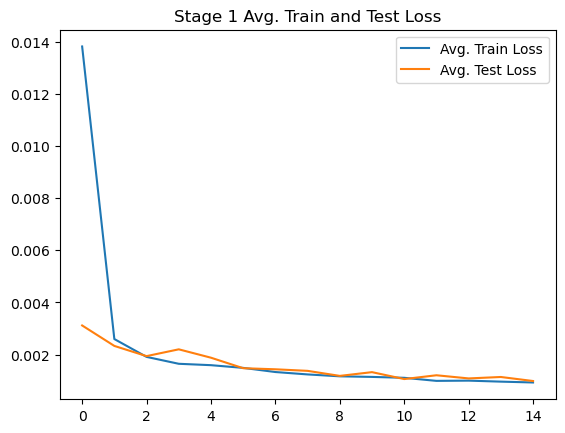

In [48]:
plt.figure()
plt.plot(south_asia_blissnet.TRAIN_LOSSES_S1, label='Avg. Train Loss')
plt.plot(south_asia_blissnet.TEST_LOSSES_S1, label='Avg. Test Loss')
plt.title("Stage 1 Avg. Train and Test Loss")
plt.legend(loc='upper right')
plt.show()

In [49]:
def plot_metric_history(train_history, test_history):
    keys = list(train_history[0].keys())
    epochs = range(1, len(train_history) + 1)

    n_keys = len(keys)
    n_rows = (n_keys + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
    axes = axes.flatten()

    for i, key in enumerate(keys):
        train_vals = [d[key] for d in train_history]
        test_vals = [d[key] for d in test_history]
        train_mean = sum(train_vals) / len(train_vals)
        test_mean = sum(test_vals) / len(test_vals)

        ax = axes[i]
        ax.plot(epochs, train_vals, label=f'train (mean={train_mean:.4f})')
        ax.plot(epochs, test_vals, label=f'test (mean={test_mean:.4f})')
        ax.set_xlabel('epoch')
        ax.set_ylabel(key)
        ax.set_title(key)
        ax.legend(loc='upper right')

    for j in range(n_keys, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

======== Stage 1 Metrics ======


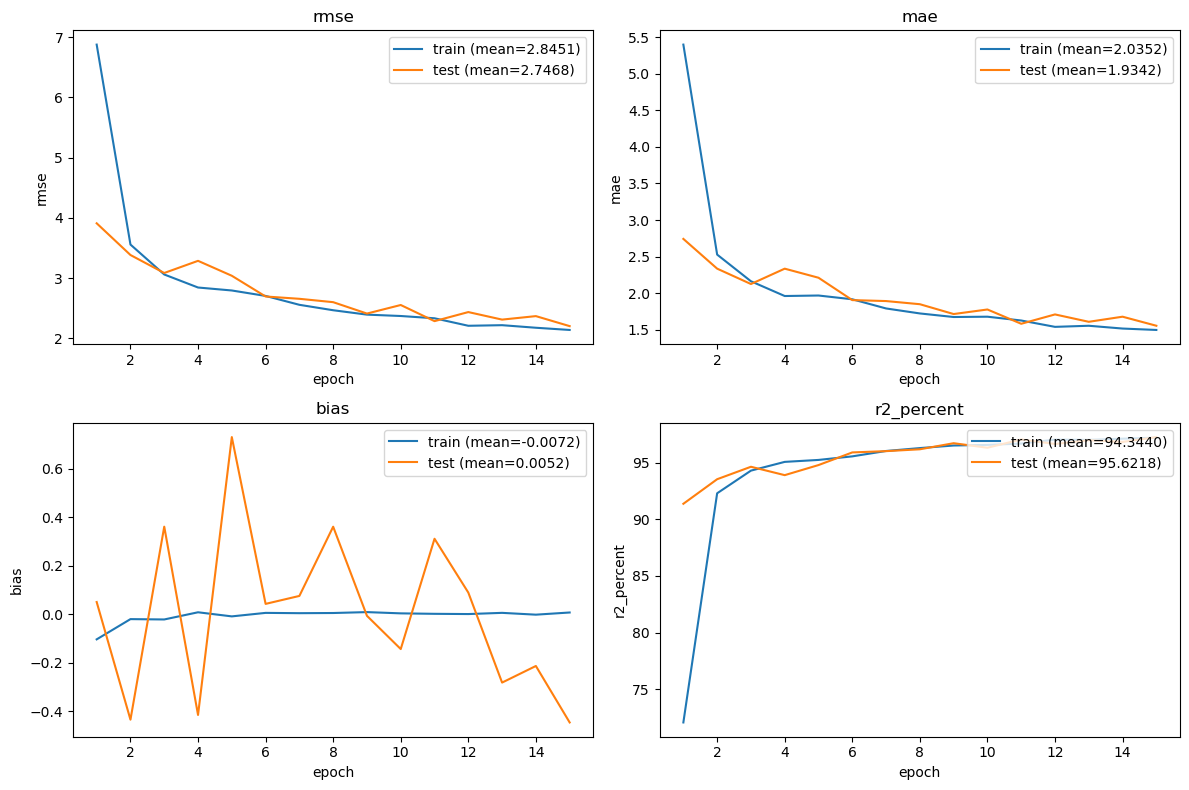

In [50]:
print("======== Stage 1 Metrics ======")
plot_metric_history(south_asia_blissnet.TRAIN_METRICS_S1, south_asia_blissnet.TEST_METRICS_S1)

======== Stage 1 Metrics ======


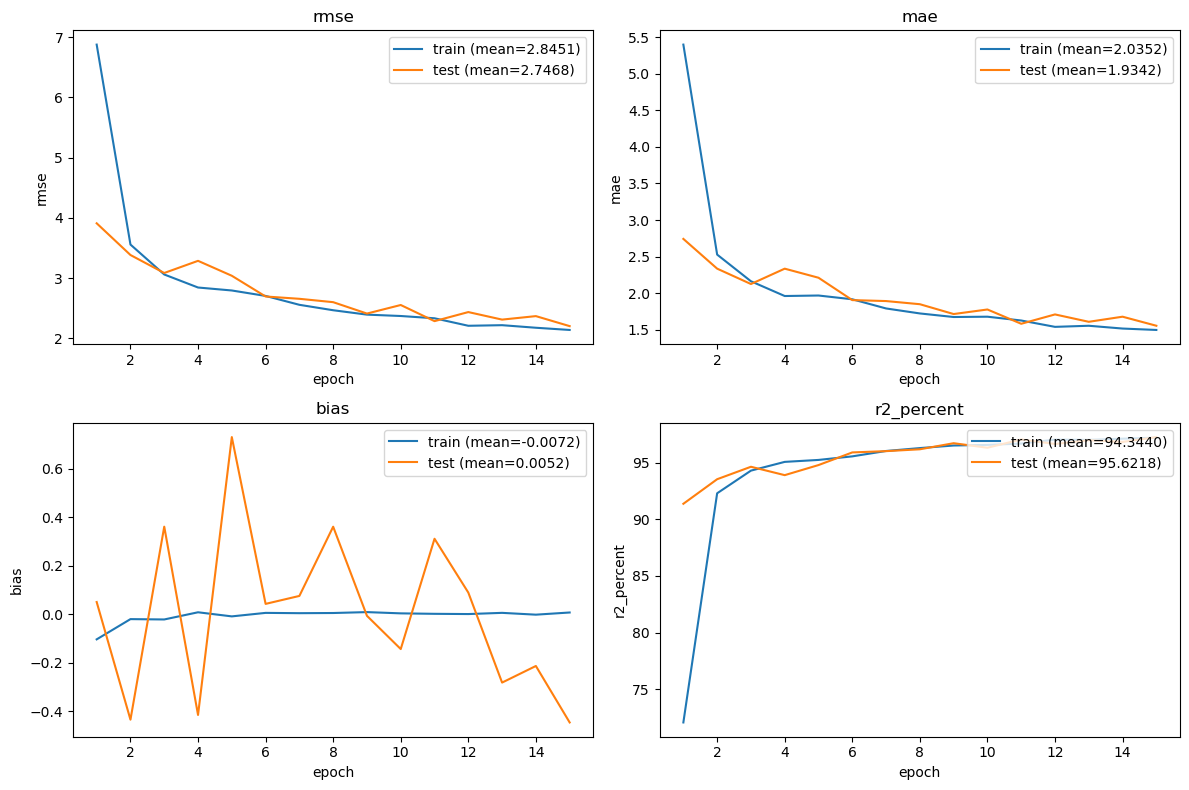

In [51]:
print("======== Stage 1 Metrics ======")
plot_metric_history(south_asia_blissnet.TRAIN_METRICS_S1, south_asia_blissnet.TEST_METRICS_S1)

### Stage 2 Metrics and Losses

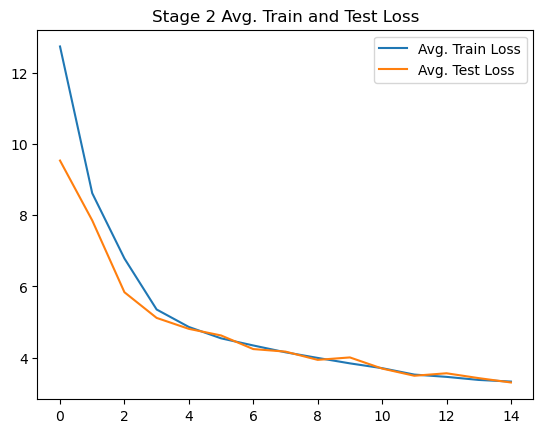

In [52]:
plt.figure()
plt.plot(south_asia_blissnet.TRAIN_LOSSES_S2, label='Avg. Train Loss')
plt.plot(south_asia_blissnet.TEST_LOSSES_S2, label='Avg. Test Loss')
plt.title("Stage 2 Avg. Train and Test Loss")
plt.legend(loc='upper right')
plt.show()

Indiviual Losses


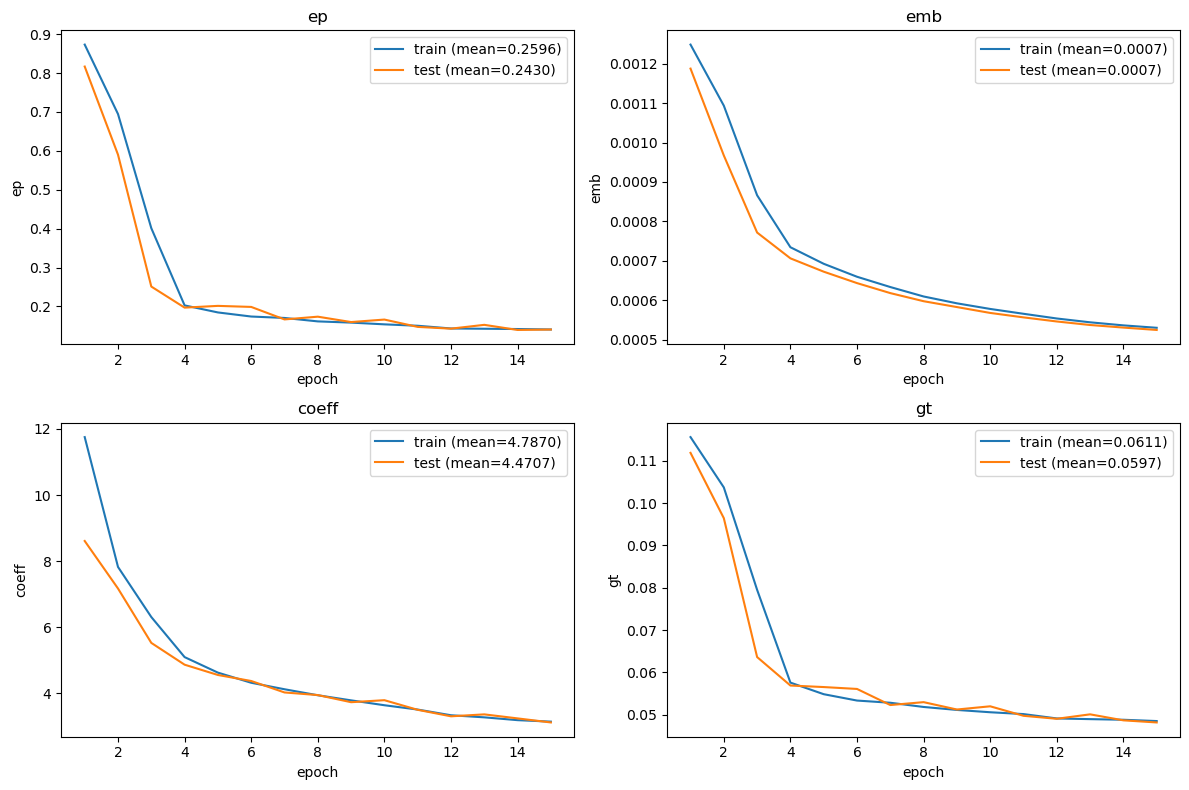

In [53]:
print("Indiviual Losses")
plot_metric_history(south_asia_blissnet.TRAIN_LOSSES_S2_COMPONENTS, south_asia_blissnet.TEST_LOSSES_S2_COMPONENTS)

======== Stage 2 Metrics ======


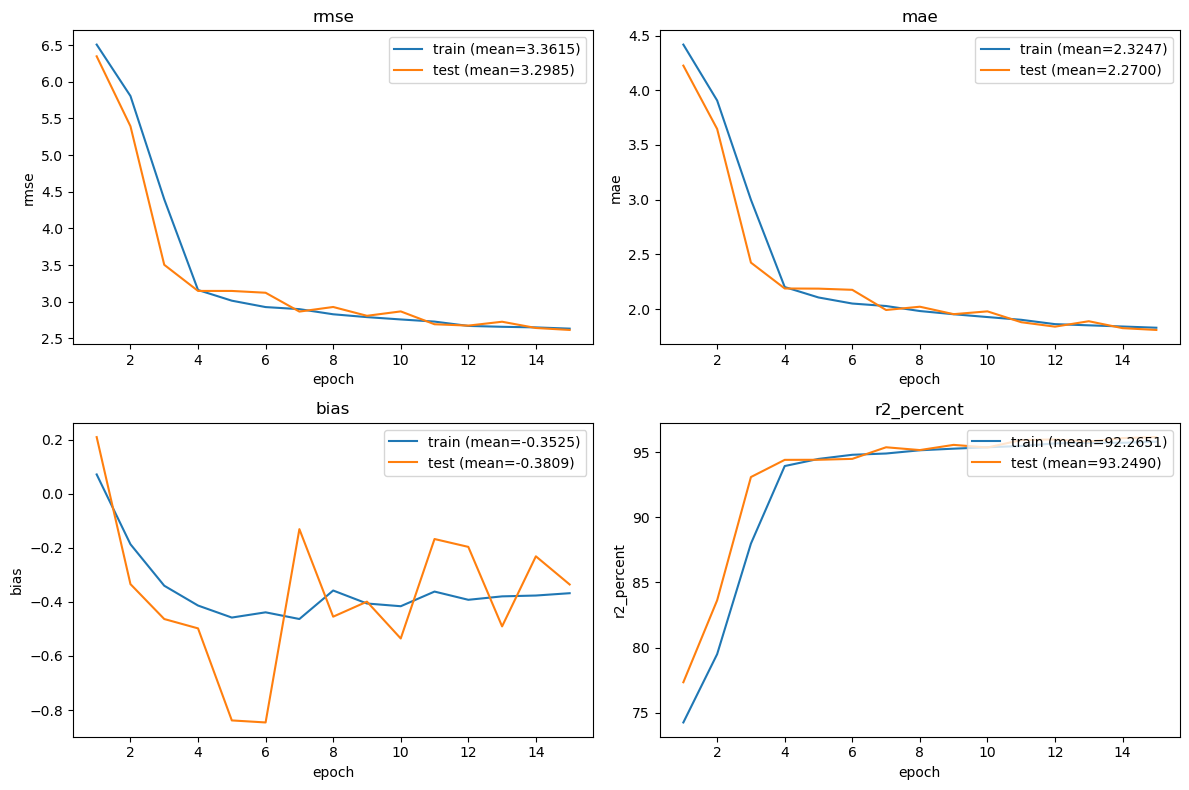

In [54]:
print("======== Stage 2 Metrics ======")
plot_metric_history(south_asia_blissnet.TRAIN_METRICS_S2, south_asia_blissnet.TEST_METRICS_S2)

### Training on Punjab Dataset

In [55]:
punjab_config = Configuration(
    batch_size=32,
    epochs=15,                 
    lr=1e-5,
    emb_dim=512,
    K=512,
    n_heads=8,
    dropout=0.1,
    in_channels=1,
    base_channels=64,
    n_groups=8,
    n_transformer_layers=4,
    n_hidden_linear_layers=3,
    siren_hidden_dim=512,
    siren_layers=4,
    omega=30
)

In [56]:
punjab_blissnet = BLISSNetTrainer(punjab_dataset, punjab_config, device, False)

In [ ]:
force_train = False
if not force_train and punjab_blissnet.load('punjab'):
    print('Loaded checkpoint.')
else:
    punjab_blissnet.train(lambda_ep, lambda_coeff, lambda_emb, lambda_gt)
    punjab_blissnet.save('punjab')
    print('Saved Model!')

========== Training Stage 1 ============


100%|██████████| 5/5 [00:00<00:00, 64.56it/s]


Epoch 1 | Train Loss: 0.0334 | Test Loss: 0.0024 | Test RMSE: 3.3964 | Test MAE: 2.6935 | Test R2: 86.83% | Test Bias: -2.0702


100%|██████████| 5/5 [00:00<00:00, 76.92it/s]


Epoch 2 | Train Loss: 0.0018 | Test Loss: 0.0020 | Test RMSE: 3.1642 | Test MAE: 2.4925 | Test R2: 88.49% | Test Bias: -1.9917


...

Epoch 13 | Train Loss: 0.2393 | Test Loss: 0.2207 | Test RMSE: 2.1213 | Test MAE: 1.5825 | Test R2: 94.86% | Test Bias: 0.0959


100%|██████████| 5/5 [00:00<00:00, 45.41it/s]


Epoch 14 | Train Loss: 0.2371 | Test Loss: 0.2201 | Test RMSE: 2.1798 | Test MAE: 1.6237 | Test R2: 94.55% | Test Bias: 0.2061


100%|██████████| 5/5 [00:00<00:00, 47.89it/s]


Epoch 15 | Train Loss: 0.2430 | Test Loss: 0.2375 | Test RMSE: 2.3255 | Test MAE: 1.7275 | Test R2: 93.79% | Test Bias: 0.6897
Saved Model!


### Stage 1 Losses and Metrics

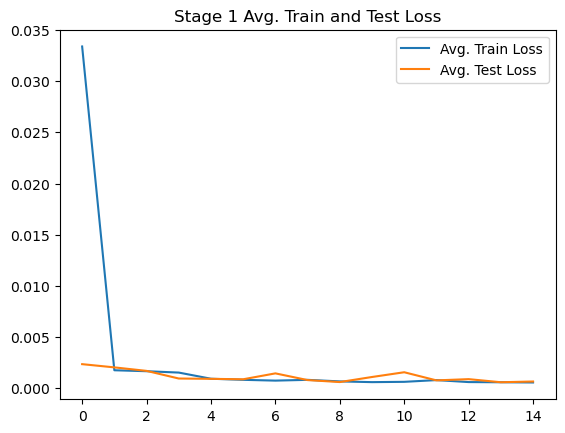

In [58]:
plt.figure()
plt.plot(punjab_blissnet.TRAIN_LOSSES_S1, label='Avg. Train Loss')
plt.plot(punjab_blissnet.TEST_LOSSES_S1, label='Avg. Test Loss')
plt.title("Stage 1 Avg. Train and Test Loss")
plt.legend(loc='upper right')
plt.show()

======== Stage 1 Metrics ======


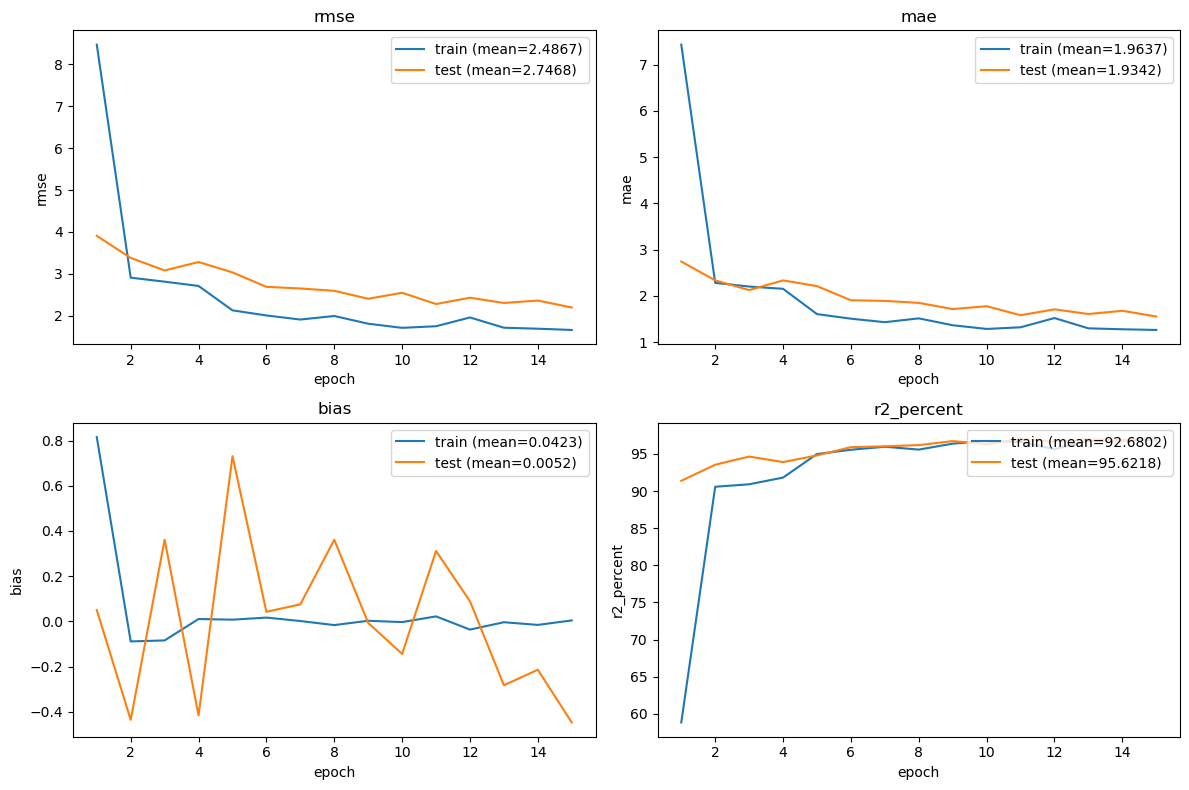

In [59]:
print("======== Stage 1 Metrics ======")
plot_metric_history(punjab_blissnet.TRAIN_METRICS_S1, south_asia_blissnet.TEST_METRICS_S1)

### Stage 2 Metrics and Losses

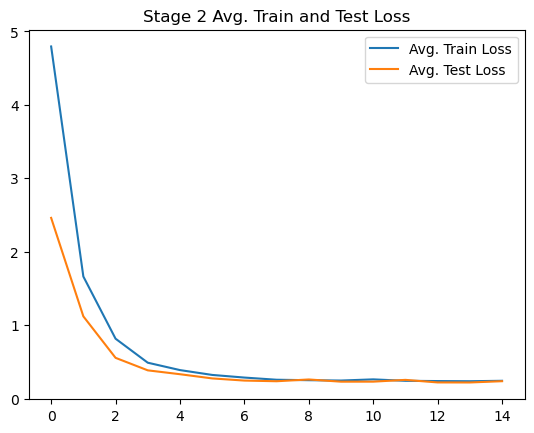

In [60]:
plt.figure()
plt.plot(punjab_blissnet.TRAIN_LOSSES_S2, label='Avg. Train Loss')
plt.plot(punjab_blissnet.TEST_LOSSES_S2, label='Avg. Test Loss')
plt.title("Stage 2 Avg. Train and Test Loss")
plt.legend(loc='upper right')
plt.show()

Indiviual Losses


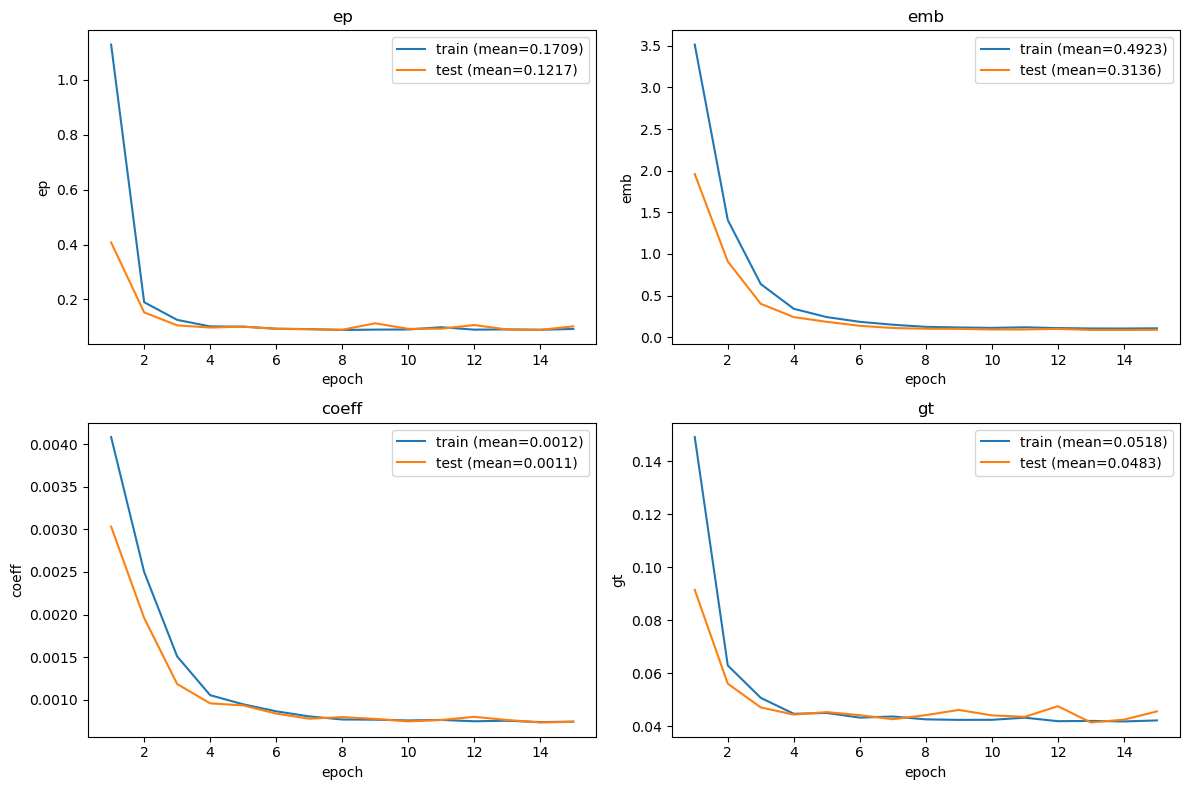

In [61]:
print("Indiviual Losses")
plot_metric_history(punjab_blissnet.TRAIN_LOSSES_S2_COMPONENTS, punjab_blissnet.TEST_LOSSES_S2_COMPONENTS)

======== Stage 2 Metrics ======


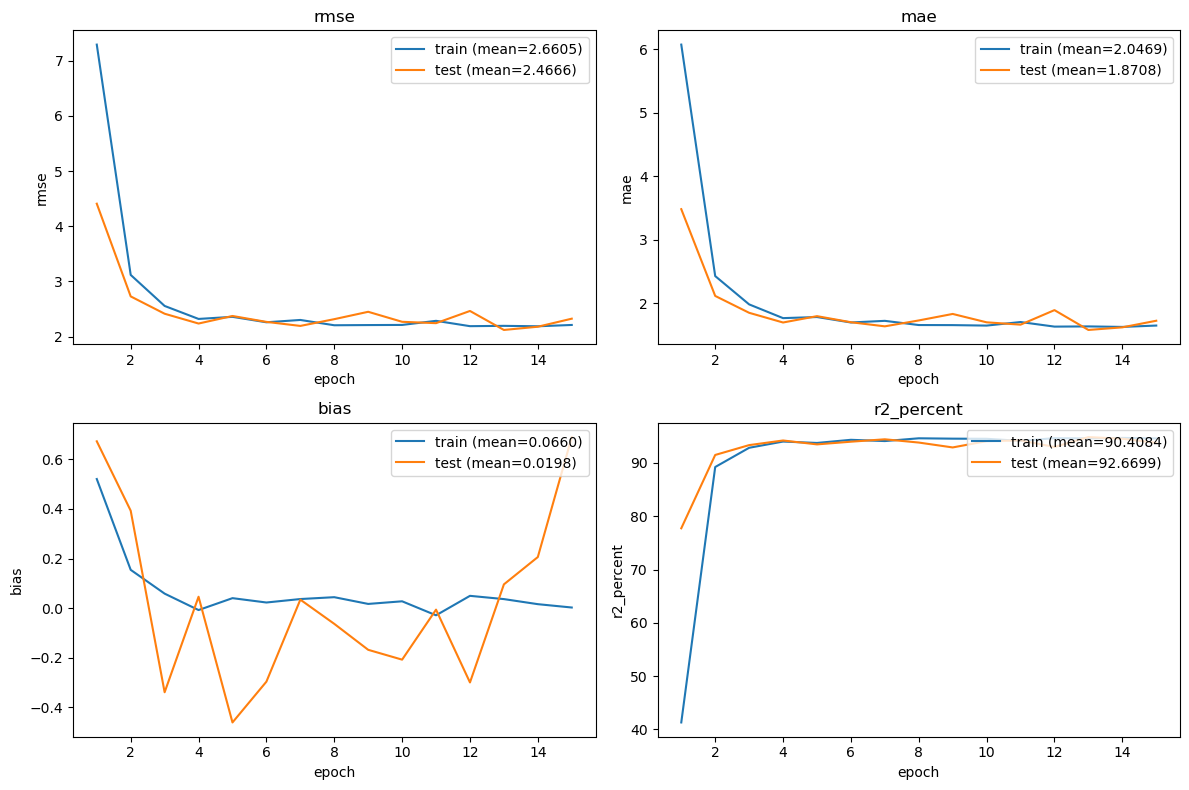

In [62]:
print("======== Stage 2 Metrics ======")
plot_metric_history(punjab_blissnet.TRAIN_METRICS_S2, punjab_blissnet.TEST_METRICS_S2)

### Training on Karnatka Dataset

In [63]:
karnatka_config = Configuration(
    batch_size=32,
    epochs=15,                 
    lr=1e-5,
    emb_dim=512,
    K=512,
    n_heads=8,
    dropout=0.1,
    in_channels=1,
    base_channels=64,
    n_groups=8,
    n_transformer_layers=4,
    n_hidden_linear_layers=3,
    siren_hidden_dim=512,
    siren_layers=4,
    omega=30
)

In [64]:
karnatka_blissnet = BLISSNetTrainer(karnatka_dataset, karnatka_config, device, False)

In [ ]:
force_train = False
if not force_train and karnatka_blissnet.load('karnatka'):
    print('Loaded checkpoint.')
else:
    karnatka_blissnet.train(lambda_ep, lambda_coeff, lambda_emb, lambda_gt)
    karnatka_blissnet.save('karnatka')
    print('Saved Model!')

========== Training Stage 1 ============


100%|██████████| 5/5 [00:00<00:00, 66.03it/s]


Epoch 1 | Train Loss: 0.0445 | Test Loss: 0.0015 | Test RMSE: 2.6890 | Test MAE: 2.0349 | Test R2: 57.47% | Test Bias: 1.2911


100%|██████████| 5/5 [00:00<00:00, 84.62it/s]


Epoch 2 | Train Loss: 0.0014 | Test Loss: 0.0006 | Test RMSE: 1.6986 | Test MAE: 1.3084 | Test R2: 82.77% | Test Bias: 0.0205


...

Epoch 13 | Train Loss: 0.1210 | Test Loss: 0.0931 | Test RMSE: 1.3078 | Test MAE: 1.0059 | Test R2: 89.73% | Test Bias: -0.1256


100%|██████████| 5/5 [00:00<00:00, 38.06it/s]


Epoch 14 | Train Loss: 0.1113 | Test Loss: 0.0970 | Test RMSE: 1.3683 | Test MAE: 1.0585 | Test R2: 88.82% | Test Bias: -0.3554


100%|██████████| 5/5 [00:00<00:00, 56.49it/s]


Epoch 15 | Train Loss: 0.1270 | Test Loss: 0.1049 | Test RMSE: 1.4702 | Test MAE: 1.1142 | Test R2: 87.30% | Test Bias: 0.1512
Saved Model!


### Stage 1 Losses and Metrics

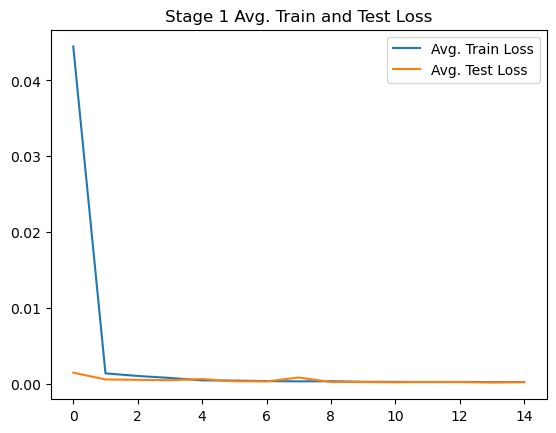

In [66]:
plt.figure()
plt.plot(karnatka_blissnet.TRAIN_LOSSES_S1, label='Avg. Train Loss')
plt.plot(karnatka_blissnet.TEST_LOSSES_S1, label='Avg. Test Loss')
plt.title("Stage 1 Avg. Train and Test Loss")
plt.legend(loc='upper right')
plt.show()

======== Stage 1 Metrics ======


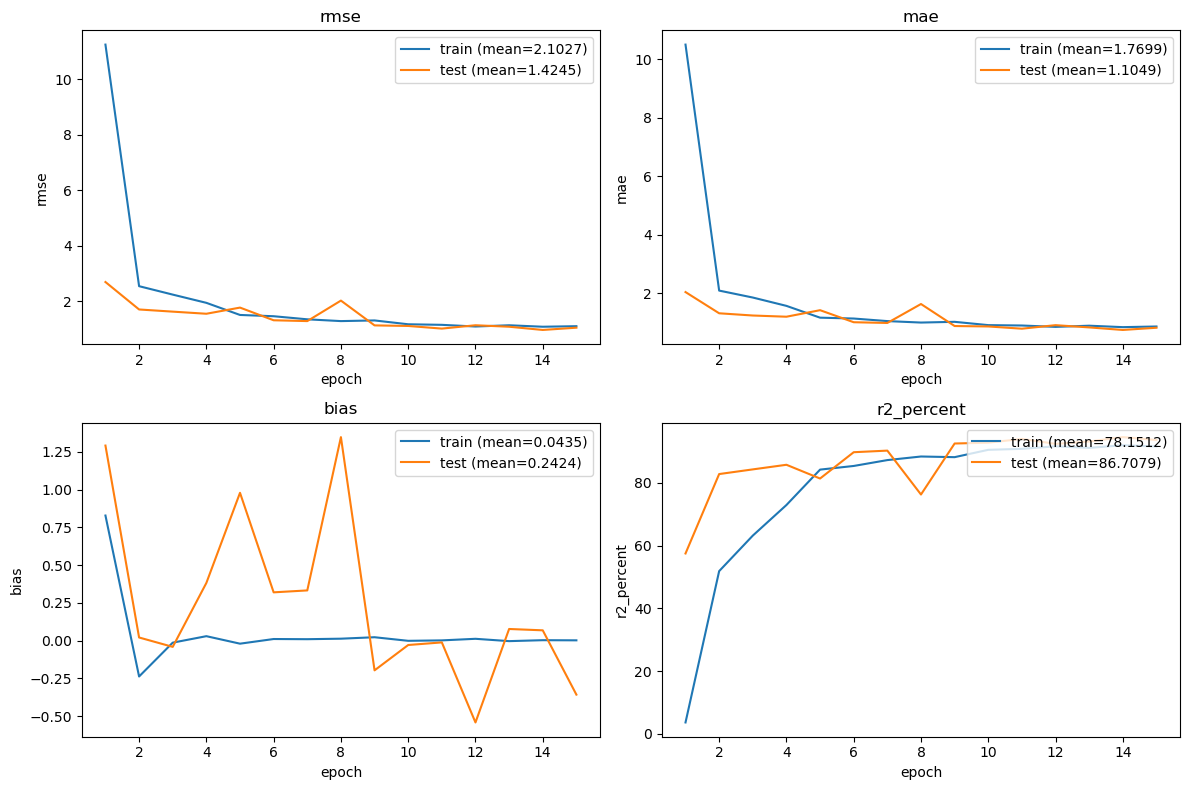

In [67]:
print("======== Stage 1 Metrics ======")
plot_metric_history(karnatka_blissnet.TRAIN_METRICS_S1, karnatka_blissnet.TEST_METRICS_S1)

### Stage 2 Losses and Metrics

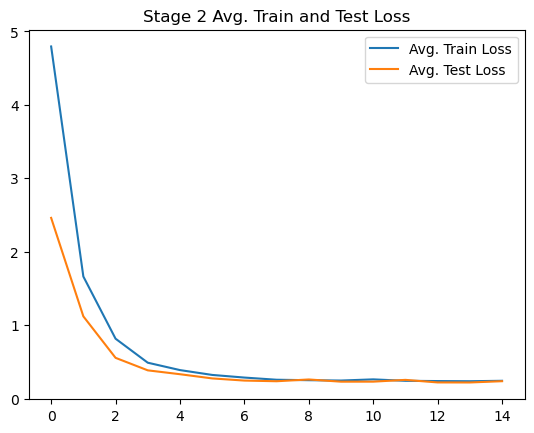

In [68]:
plt.figure()
plt.plot(punjab_blissnet.TRAIN_LOSSES_S2, label='Avg. Train Loss')
plt.plot(punjab_blissnet.TEST_LOSSES_S2, label='Avg. Test Loss')
plt.title("Stage 2 Avg. Train and Test Loss")
plt.legend(loc='upper right')
plt.show()

Indiviual Losses


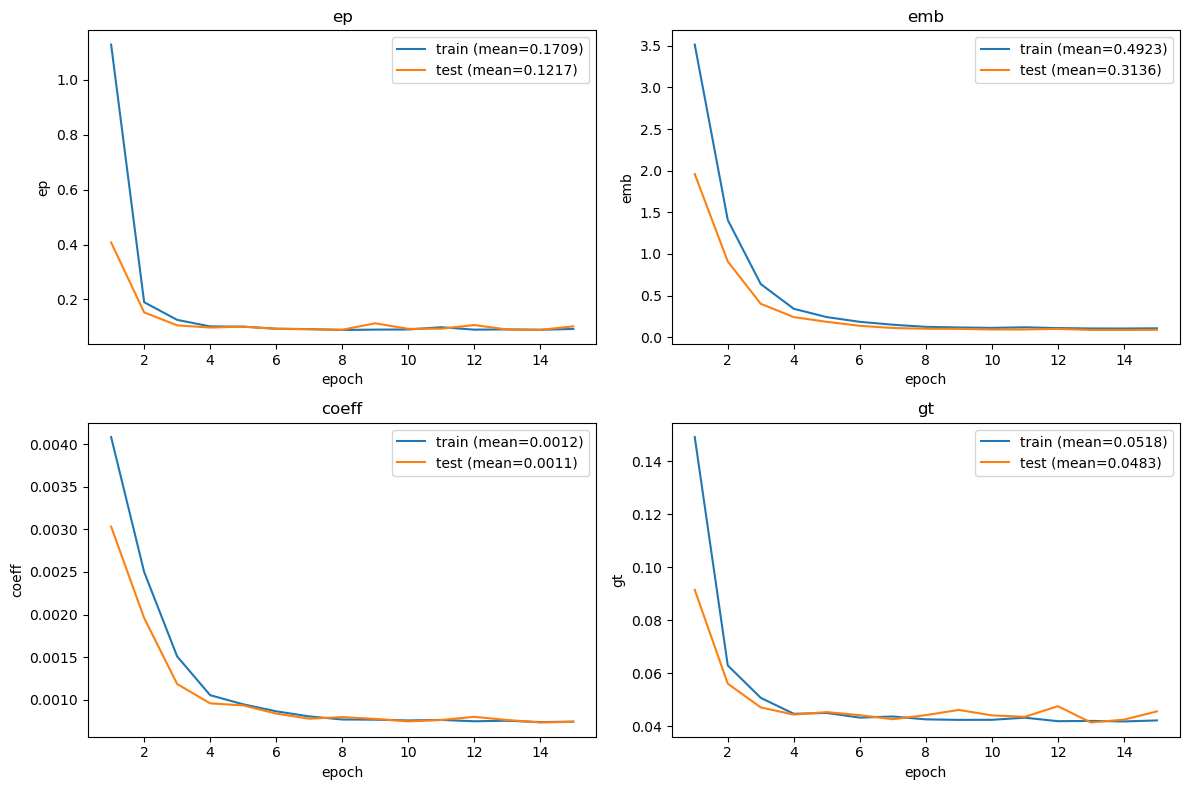

In [69]:
print("Indiviual Losses")
plot_metric_history(punjab_blissnet.TRAIN_LOSSES_S2_COMPONENTS, punjab_blissnet.TEST_LOSSES_S2_COMPONENTS)

======== Stage 2 Metrics ======


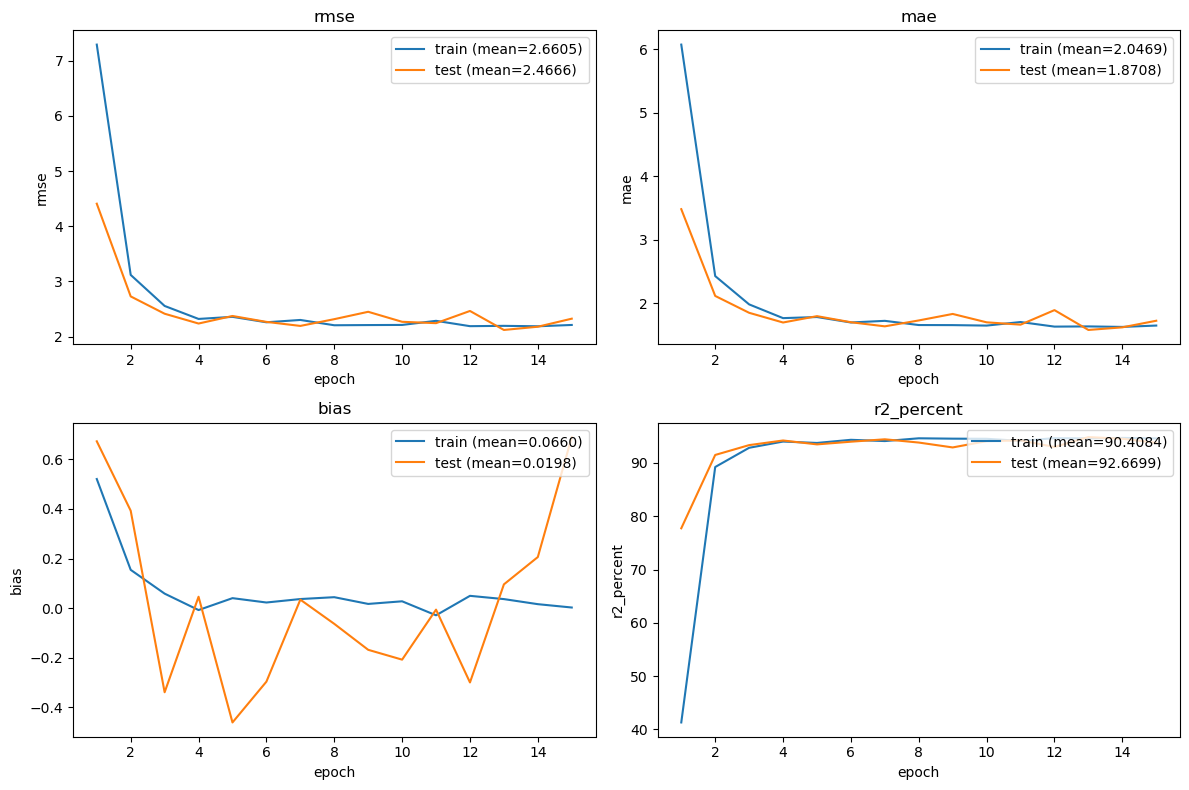

In [70]:
print("======== Stage 2 Metrics ======")
plot_metric_history(punjab_blissnet.TRAIN_METRICS_S2, punjab_blissnet.TEST_METRICS_S2)